# 5 · Promptovací strategie a volba modelu

**Odpovídá sekci 4.2 práce — Strategie 1**, část *Optimalizace jazykových modelů
a promptování* (Obrázky 4.4–4.8, Tabulka 4.2).

Notebook uzavírá návrh textové větve pipeline dvěma navazujícími fázemi:

| Fáze | Otázka | Uspořádání |
|---|---|---|
| **Fáze 1** | Jak formulovat instrukci? | jeden model (GPT‑4.1 nano), čtyři strategie |
| **Fáze 2** | Který model použít? | jedna strategie (vítěz Fáze 1), sedm modelů |

Levný model ve Fázi 1 je záměr: rozdíly mezi strategiemi se na slabším modelu
projeví nejvýrazněji, a experiment je zároveň řádově levnější.

## Testované promptovací strategie

| Strategie | Popis |
|---|---|
| **zero_shot** | minimální prompt — role, kontext a seznam polí |
| **zero_shot_rules** | zero-shot doplněný o explicitní pravidla pro formát hodnot |
| **few_shot** | prompt obohacený o dvě syntetické ukázky vstup/výstup |
| **chain_of_thought** | instrukce k explicitnímu trasování důkazů před generováním JSON |

Ukázky u `few_shot` jsou syntetické, takže nedochází k úniku dat z testovací sady.

| | |
|---|---|
| **Datová sada** | DS2 |
| **Upstream** | fixováno z notebooků `02`–`04` (P4 + JSON-light + cs_en) |

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
faze1 = pd.read_csv(DATA / "05_strategie_modely" / "phase1_strategie.csv")
faze1_naklady = pd.read_csv(DATA / "05_strategie_modely" / "phase1_naklady.csv")
faze2 = pd.read_csv(DATA / "05_strategie_modely" / "nb05_results.csv")

PORADI_STRATEGII = ["few_shot", "zero_shot", "chain_of_thought"]
VITEZNA_STRATEGIE = "few_shot"

print(f"Fáze 1 : {len(faze1)} měření, {faze1.strategie.nunique()} strategií")
print(f"Fáze 2 : {len(faze2)} měření, {faze2.model_label.nunique()} modelů")

Fáze 1 : 480 měření, 4 strategií
Fáze 2 : 966 měření, 7 modelů


## 5.1 Fáze 1 — přesnost a cena strategií (Obrázek 4.4 v práci)

**Přesnost extrakce** je podíl polí, u nichž se extrahovaná hodnota přesně shoduje
s referenční. Do jmenovatele vstupují pouze pole, která na faktuře skutečně jsou.

Strategie `zero_shot_rules` se v hlavním srovnání nezobrazuje — v práci nebyla
dále rozvíjena, její hodnoty jsou v doplňkové tabulce níže.

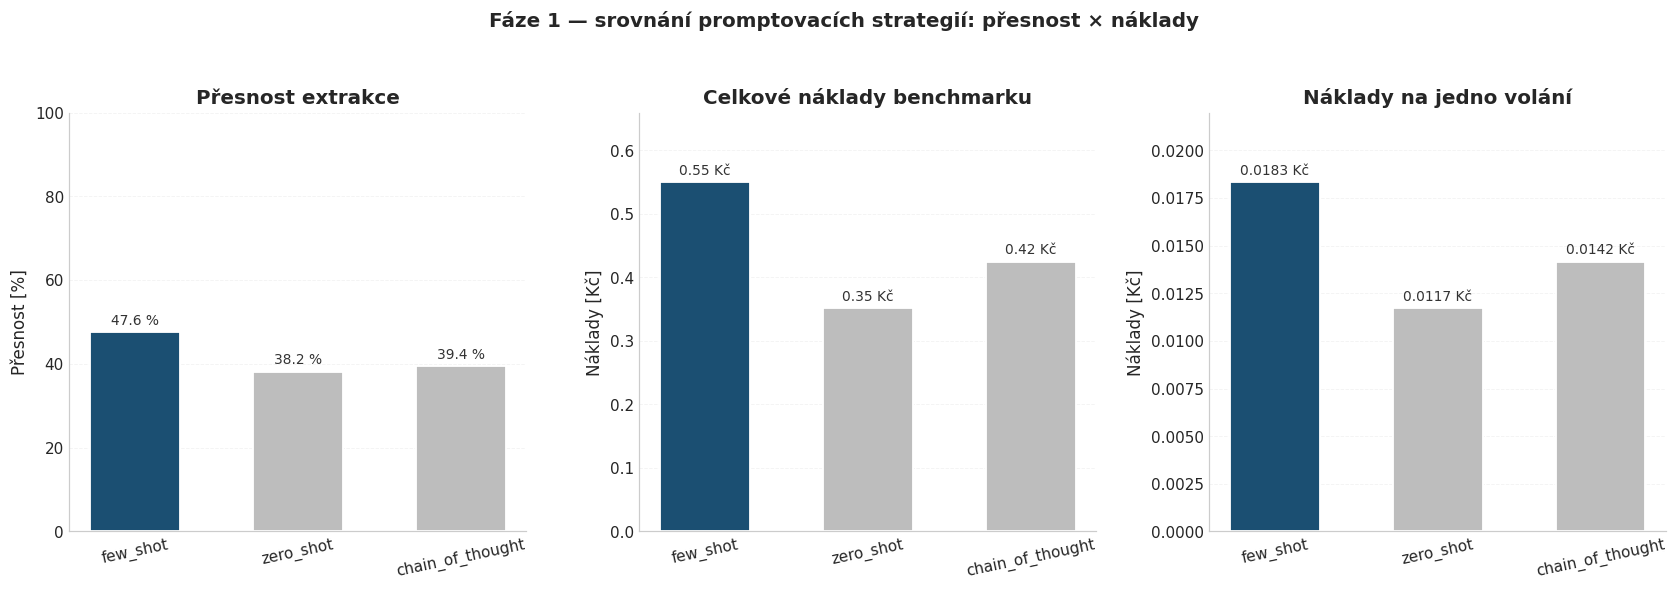

,Přesnost extrakce [%],Náklady na volání [Kč],Náklady celkem [Kč]
strategie,,,
few_shot,47.6000,0.0183,0.5500
zero_shot,38.2000,0.0117,0.3500
chain_of_thought,39.4000,0.0142,0.4200


In [3]:
def presnost_extrakce(skupina):
    return 100 * skupina.pole_spravne.sum() / skupina.pole_celkem.sum()

presnost = (faze1.groupby("strategie").apply(presnost_extrakce, include_groups=False)
                 .reindex(PORADI_STRATEGII))
naklady = (faze1_naklady.groupby("strategie")
                        .agg(na_volani=("cost_czk", "mean"), celkem=("cost_czk", "sum"))
                        .reindex(PORADI_STRATEGII))

fig, osy = plt.subplots(1, 3, figsize=(15.5, 5.2))
barvy = barvy_vitez(PORADI_STRATEGII, vitez=VITEZNA_STRATEGIE)

osy[0].bar(PORADI_STRATEGII, presnost, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[0], fmt="{:.1f} %")
osy[0].set_ylim(0, 100)
uprav_osu(osy[0], "Přesnost extrakce", y="Přesnost [%]")

osy[1].bar(PORADI_STRATEGII, naklady.celkem, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[1], fmt="{:.2f} Kč")
osy[1].set_ylim(0, naklady.celkem.max() * 1.2)
uprav_osu(osy[1], "Celkové náklady benchmarku", y="Náklady [Kč]")

osy[2].bar(PORADI_STRATEGII, naklady.na_volani, color=barvy, width=0.55,
           edgecolor="white", linewidth=1.2)
popisky_sloupcu(osy[2], fmt="{:.4f} Kč")
osy[2].set_ylim(0, naklady.na_volani.max() * 1.2)
uprav_osu(osy[2], "Náklady na jedno volání", y="Náklady [Kč]")

for ax in osy:
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="x", rotation=12)

fig.suptitle("Fáze 1 — srovnání promptovacích strategií: přesnost × náklady",
             fontsize=13, fontweight="semibold", y=1.03)
fig.tight_layout()
plt.show()

prehled1 = pd.DataFrame({
    "Přesnost extrakce [%]": presnost.round(1),
    "Náklady na volání [Kč]": naklady.na_volani.round(4),
    "Náklady celkem [Kč]": naklady.celkem.round(2),
})
display(tabulka(prehled1, desetinna=4))

> **Zjištění.** Nejlépe si vede `few_shot` (**47,6 %**) s výrazným náskokem před
> `zero_shot` (38,2 %) a `chain_of_thought` (39,4 %). Zavedení řetězce úvah
> zlepšilo přesnost oproti holému zero-shotu jen minimálně, zatímco dvě syntetické
> ukázky přinesly skok o devět procentních bodů.
>
> Cenově je `few_shot` nejdražší (0,0183 Kč za volání) proti 0,0117 Kč u
> `zero_shot`, rozdíl v řádu setin haléře je ale vzhledem k nárůstu přesnosti
> zanedbatelný.

## 5.2 Proč řetězec úvah nepomohl (Obrázek 4.5 v práci)

Chování vysvětlují dvě doplňkové metriky:

* **Null-rate** — jak často model nechá pole prázdné, přestože na faktuře je.
* **Poměr Precision / Recall** — zda model spíš chybuje, nebo spíš mlčí.

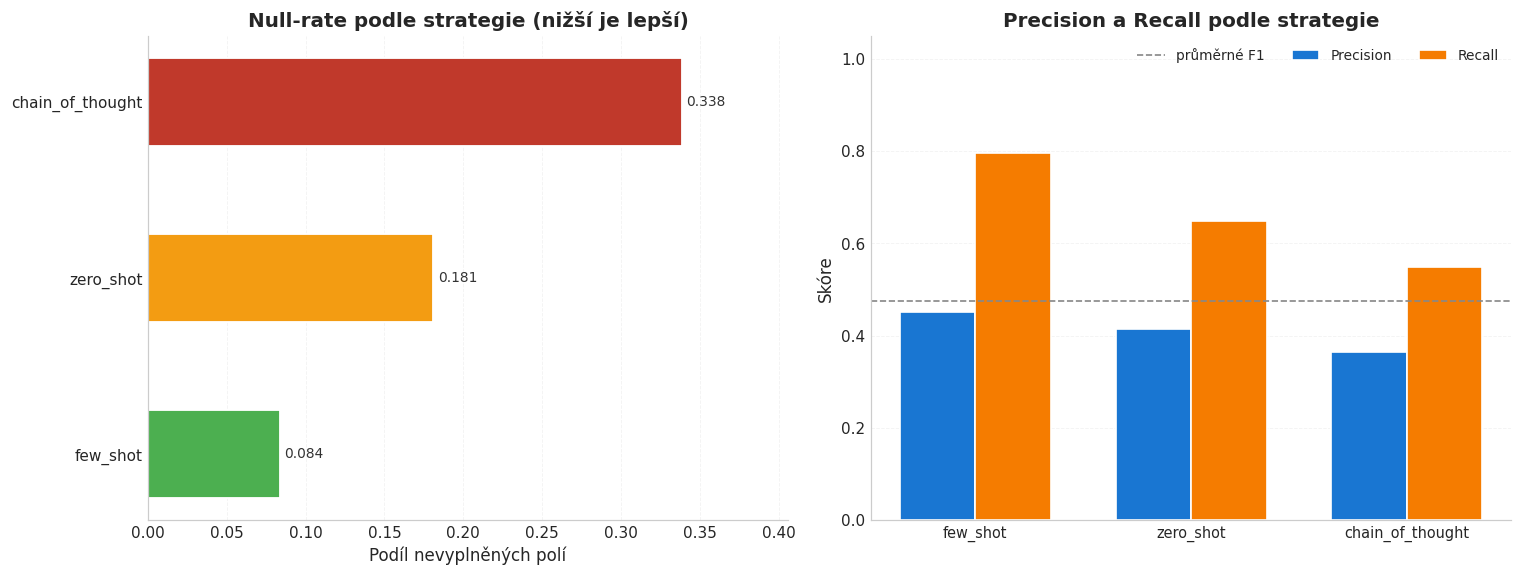

,null_rate,precision,recall,f1
strategie,,,,
few_shot,0.0836,0.4519,0.7956,0.5512
zero_shot,0.1811,0.4134,0.6490,0.4633
chain_of_thought,0.3384,0.3646,0.5485,0.4074


In [4]:
metriky = (faze1.groupby("strategie")
                .agg(null_rate=("null_rate", "mean"), precision=("precision", "mean"),
                     recall=("recall", "mean"), f1=("f1", "mean"))
                .reindex(PORADI_STRATEGII))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))

poradi_null = metriky.null_rate.sort_values()
barvy_null = ["#4CAF50" if s == poradi_null.index[0] else
              "#C0392B" if s == poradi_null.index[-1] else "#F39C12"
              for s in poradi_null.index]
sloupce = ax1.barh(list(poradi_null.index), poradi_null.to_numpy(),
                   color=barvy_null, height=0.5, edgecolor="white", linewidth=1.2)
popisky_sloupcu(ax1, fmt="{:.3f}", vodorovne=True)
ax1.set_xlim(0, poradi_null.max() * 1.2)
uprav_osu(ax1, "Null-rate podle strategie (nižší je lepší)",
          x="Podíl nevyplněných polí")
ax1.grid(axis="y", visible=False)

x, sirka = np.arange(len(PORADI_STRATEGII)), 0.35
ax2.bar(x - sirka / 2, metriky.precision, sirka, label="Precision",
        color="#1976D2", edgecolor="white", linewidth=1.1)
ax2.bar(x + sirka / 2, metriky.recall, sirka, label="Recall",
        color="#F57C00", edgecolor="white", linewidth=1.1)
ax2.axhline(metriky.f1.mean(), linestyle="--", color="#888888", linewidth=1.1,
            label="průměrné F1")
ax2.set_xticks(x)
ax2.set_xticklabels(PORADI_STRATEGII, fontsize=9.5)
ax2.set_ylim(0, 1.05)
uprav_osu(ax2, "Precision a Recall podle strategie", y="Skóre")
ax2.legend(frameon=False, fontsize=9, ncol=3)
ax2.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

display(tabulka(metriky.round(4), desetinna=4))

> **Zjištění.** `chain_of_thought` vede k **nadměrné opatrnosti modelu**: null-rate
> dosahuje 33,8 %, nejvíce ze všech strategií. Mechanismus řetězce úvah nutí model
> explicitně zdůvodnit každý údaj před jeho zapsáním, a u menších architektur
> s omezenou kapacitou kontextového okna to vede k tomu, že model v případě
> sebemenší nejistoty pole raději nevyplní — klesá tím Recall.
>
> `few_shot` má naopak nejnižší null-rate (8,4 %) a nejvyšší Recall. Ukázky ve
> vstupu modelu jasně ukotví, co se od něj čeká, a on se pak méně zdráhá pole
> vyplnit.

In [5]:
# Doplňkově: čtvrtá testovaná strategie, která se v práci dále nerozvíjí
vsechny = (faze1.groupby("strategie")
                .agg(null_rate=("null_rate", "mean"), precision=("precision", "mean"),
                     recall=("recall", "mean"), f1=("f1", "mean"), n=("f1", "size")))
vsechny["presnost_extrakce_%"] = faze1.groupby("strategie").apply(
    presnost_extrakce, include_groups=False)
display(tabulka(vsechny.sort_values("presnost_extrakce_%", ascending=False).round(4)))

,null_rate,precision,recall,f1,n,presnost_extrakce_%
strategie,,,,,,
few_shot,0.084,0.452,0.796,0.551,120,47.634
zero_shot_rules,0.261,0.426,0.603,0.450,120,40.694
chain_of_thought,0.338,0.365,0.548,0.407,120,39.432
zero_shot,0.181,0.413,0.649,0.463,120,38.170


## 5.3 Fáze 2 — srovnání modelů (Tabulka 4.2 a Obrázek 4.6 v práci)

Všechny modely běží se stejnou strategií `few_shot`, aby bylo srovnání férové.
Testovány jsou odlehčené varianty `mini` a `nano` i plnohodnotné GPT‑4.1 a GPT‑4o.

> V době provádění experimentů byla nejnovější dostupnou řadou modelů OpenAI
> GPT‑4 (varianty GPT‑4.1 a GPT‑4o včetně odlehčených verzí mini/nano).

In [6]:
poradi_modelu = (faze2.groupby("model_label").f1.mean()
                      .sort_values(ascending=False).index.tolist())
NEJLEPSI_MODEL = poradi_modelu[0]
PRODUKCNI_MODEL = "GPT-4.1"

souhrn_modelu = (faze2.groupby("model_label")
                      .agg(**{"Průměrné F1": ("f1", "mean"),
                              "Medián F1": ("f1", "median"),
                              "Precision": ("precision", "mean"),
                              "Recall": ("recall", "mean"),
                              "Null-rate": ("null_rate", "mean"),
                              "Latence [ms]": ("latency_ms", "mean"),
                              "Náklady [USD]": ("cost_usd", "sum")})
                      .reindex(poradi_modelu))
display(tabulka(souhrn_modelu.round(4), desetinna=4))

,Průměrné F1,Medián F1,Precision,Recall,Null-rate,Latence [ms],Náklady [USD]
model_label,,,,,,,
GPT-4.1 Apr-25,0.6569,0.7143,0.6290,0.7345,0.1851,1747.8715,2.3807
GPT-4.1,0.6532,0.7059,0.6247,0.7350,0.1849,1880.8789,2.3805
GPT-4o,0.6280,0.6863,0.5972,0.7274,0.1963,1931.9889,2.9758
GPT-4o Nov-24,0.6020,0.6863,0.5816,0.6951,0.2662,1396.2861,2.9720
GPT-4.1 mini,0.5925,0.6250,0.5807,0.6768,0.2407,1934.3170,0.4762
GPT-4o mini,0.5798,0.6250,0.5128,0.7812,0.1892,3180.4656,0.1784
GPT-4.1 nano,0.5380,0.5714,0.4481,0.7670,0.1386,1590.7516,0.1206


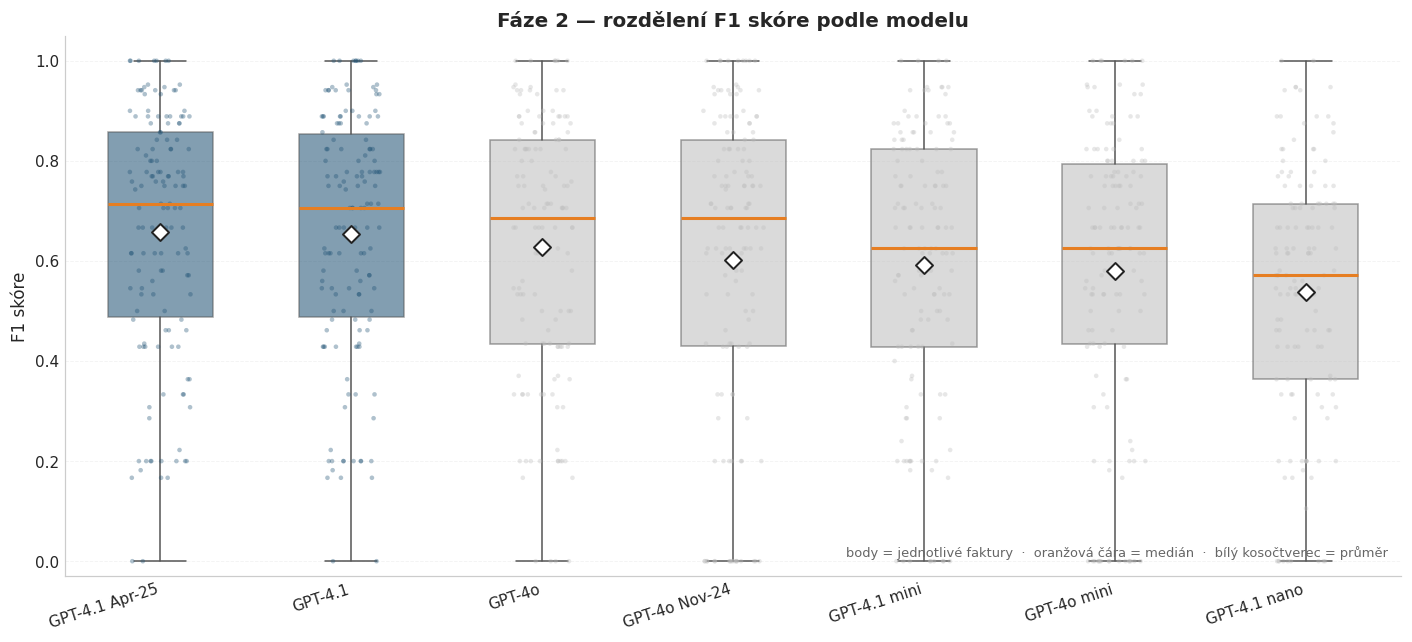

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
data = [faze2.loc[faze2.model_label == m, "f1"].to_numpy() for m in poradi_modelu]
barvy = [VITEZ if m in (NEJLEPSI_MODEL, PRODUKCNI_MODEL) else NEUTRALNI
         for m in poradi_modelu]

bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False,
                medianprops=dict(color="#E67E22", linewidth=2.0),
                whiskerprops=dict(color="#555555"), capprops=dict(color="#555555"))
for telo, barva in zip(bp["boxes"], barvy):
    telo.set_facecolor(barva)
    telo.set_alpha(0.55)
    telo.set_edgecolor("#555555")

rng = np.random.default_rng(7)
for i, (hodnoty, barva) in enumerate(zip(data, barvy), start=1):
    ax.scatter(i + rng.uniform(-0.16, 0.16, len(hodnoty)), hodnoty, s=9,
               color=barva, alpha=0.35, edgecolor="none", zorder=2)
    ax.scatter(i, hodnoty.mean(), marker="D", s=62, facecolor="white",
               edgecolor="#222222", linewidth=1.3, zorder=4)

ax.set_xticklabels(poradi_modelu, rotation=18, ha="right")
ax.set_ylim(-0.03, 1.05)
uprav_osu(ax, "Fáze 2 — rozdělení F1 skóre podle modelu", y="F1 skóre")
ax.text(0.99, 0.03,
        "body = jednotlivé faktury  ·  oranžová čára = medián  ·  bílý kosočtverec = průměr",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5, color="#666666")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

> **Zjištění.** Obě varianty GPT‑4.1 vedou (0,66 a 0,65), rozdíl mezi nimi je
> vzhledem k rozptylu jednotlivých faktur zanedbatelný a lze je považovat za
> rovnocenné. Odlehčené modely zaostávají o 6–12 bodů, což je při jejich nižší
> ceně očekávatelné.

## 5.4 Rozpad podle komodit (Obrázky 4.7 a 4.8 v práci)

Zajímá nás nejen průměr, ale i to, zda některý model selhává na konkrétní komoditě.

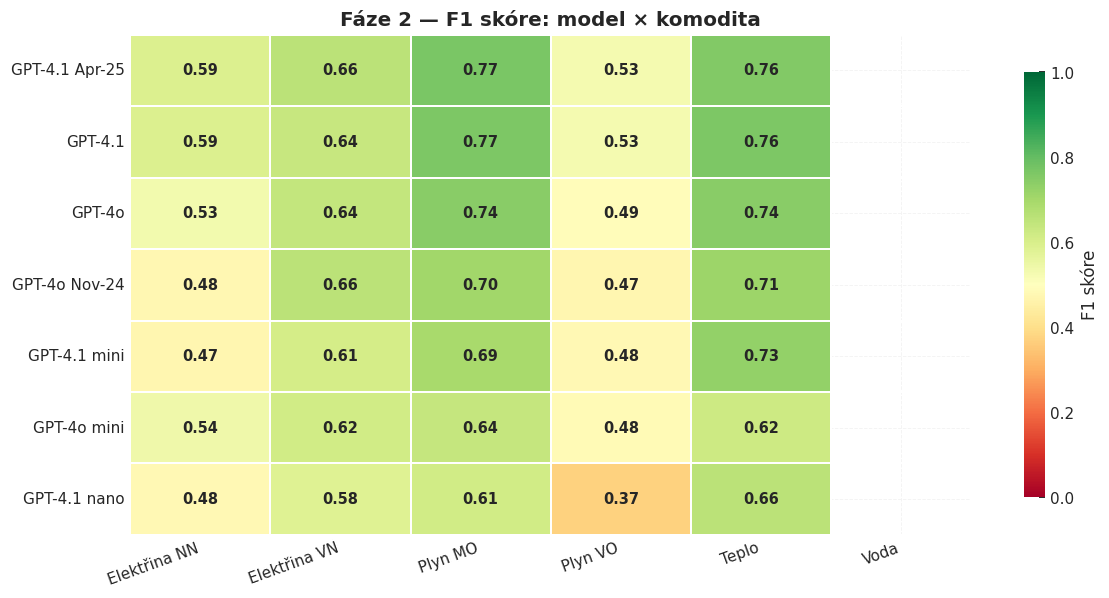

In [8]:
heatmapa = (faze2.pivot_table(index="model_label", columns="commodity",
                              values="f1", aggfunc="mean")
                 .reindex(index=poradi_modelu, columns=KOMODITY))

fig, ax = plt.subplots(figsize=(11, 5.6))
import seaborn as sns
sns.heatmap(heatmapa, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1.0,
            linewidths=1.2, linecolor="white", ax=ax,
            cbar_kws={"label": "F1 skóre", "shrink": 0.85},
            annot_kws={"fontsize": 9.5, "fontweight": "600"})
ax.set_xticklabels([NAZVY_KOMODIT[k] for k in heatmapa.columns], rotation=20, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
uprav_osu(ax, "Fáze 2 — F1 skóre: model × komodita", x="", y="")
fig.tight_layout()
plt.show()

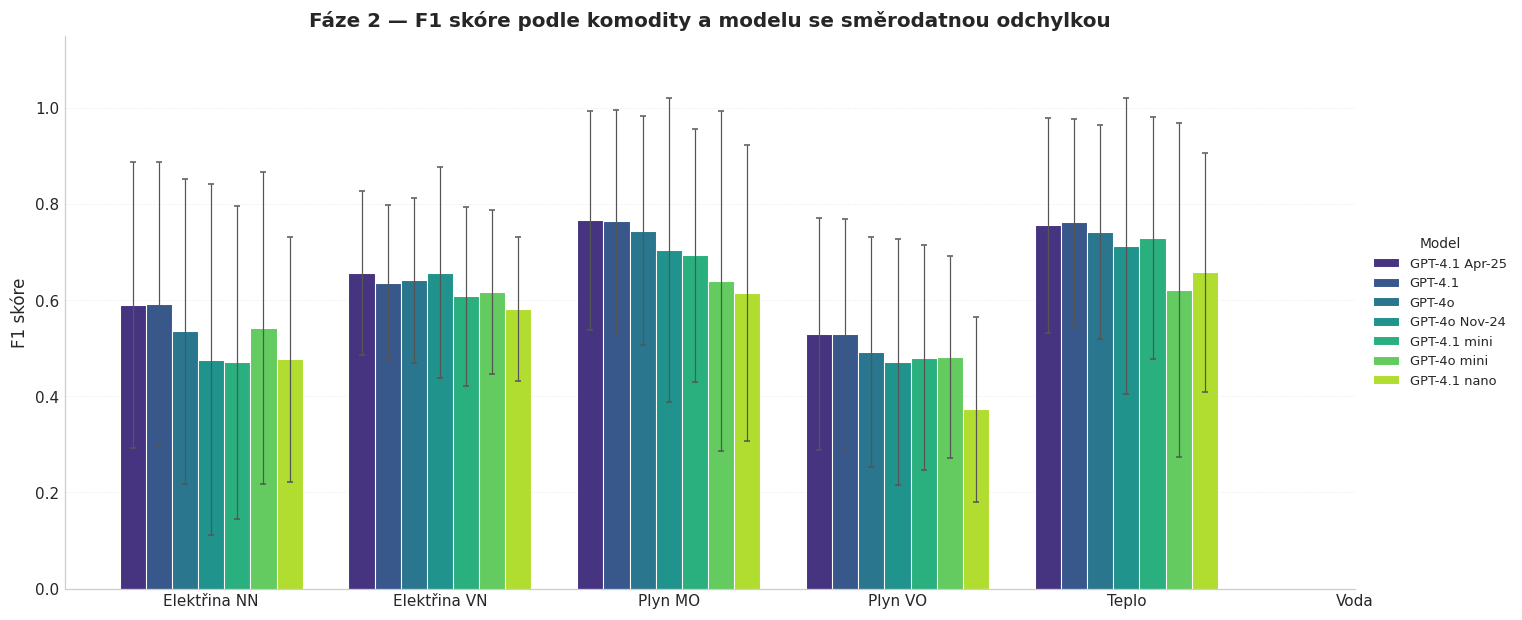

Velký rozptyl odráží variabilitu faktur ve vývojové sadě DS2.


model_label,GPT-4.1 Apr-25,GPT-4.1,GPT-4o,GPT-4o Nov-24,GPT-4.1 mini,GPT-4o mini,GPT-4.1 nano
commodity,,,,,,,
Elektřina NN,0.590,0.590,0.530,0.480,0.470,0.540,0.480
Elektřina VN,0.660,0.640,0.640,0.660,0.610,0.620,0.580
Plyn MO,0.770,0.770,0.740,0.700,0.690,0.640,0.610
Plyn VO,0.530,0.530,0.490,0.470,0.480,0.480,0.370
Teplo,0.760,0.760,0.740,0.710,0.730,0.620,0.660
Voda,nan,nan,nan,nan,nan,nan,nan


In [9]:
smerodatna = (faze2.pivot_table(index="commodity", columns="model_label",
                                values="f1", aggfunc="std")
                   .reindex(index=KOMODITY, columns=poradi_modelu))
prumery = (faze2.pivot_table(index="commodity", columns="model_label",
                             values="f1", aggfunc="mean")
                .reindex(index=KOMODITY, columns=poradi_modelu))

fig, ax = plt.subplots(figsize=(14, 5.8))
x = np.arange(len(KOMODITY))
sirka = 0.8 / len(poradi_modelu)
paleta = plt.cm.viridis(np.linspace(0.15, 0.88, len(poradi_modelu)))
for i, model in enumerate(poradi_modelu):
    ax.bar(x + (i - len(poradi_modelu) / 2 + 0.5) * sirka, prumery[model], sirka,
           yerr=smerodatna[model], label=model, color=paleta[i],
           edgecolor="white", linewidth=0.7,
           error_kw=dict(ecolor="#555555", lw=0.8, capsize=1.8))

ax.set_xticks(x)
ax.set_xticklabels([NAZVY_KOMODIT[k] for k in KOMODITY])
ax.set_ylim(0, 1.15)
uprav_osu(ax, "Fáze 2 — F1 skóre podle komodity a modelu se směrodatnou odchylkou",
          y="F1 skóre")
ax.legend(title="Model", frameon=False, fontsize=8.5, title_fontsize=9,
          loc="center left", bbox_to_anchor=(1.005, 0.5))
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print("Velký rozptyl odráží variabilitu faktur ve vývojové sadě DS2.")
display(tabulka(prumery.round(2).rename(index=NAZVY_KOMODIT)))

## Závěr

**Zvolená konfigurace textové větve: model `GPT-4.1`, strategie `few_shot`,
hybridní prompt `cs_en` — F1 = 0,66 na DS2.**

| Rozhodnutí | Odůvodnění |
|---|---|
| `few_shot` místo `zero_shot` | +9 p. b. přesnosti za náklad v řádu setin haléře |
| `few_shot` místo `chain_of_thought` | řetězec úvah zvyšuje null-rate na 33,8 % |
| `GPT-4.1` místo odlehčených variant | rozdíl 6–12 bodů F1 je pro produkční nasazení podstatný |

Slabší modely potřebovaly ukázky `few_shot` nejvýrazněji, srovnání ve Fázi 2 ale
proběhlo se stejnou strategií pro všechny modely včetně plnohodnotného GPT‑4.1 —
a i tam zůstává `few_shot` volbou s nejlepším poměrem přesnosti a ceny.

Tato konfigurace tvoří **hlavní (primární) cestu** finální kaskádové pipeline.
Notebook `06` zkoumá alternativu bez OCR, která se stane cestou záložní.